# Dental Image & Mask Resizing for 3 Models

**Objective**: Resize dental X-ray images and masks to model-specific sizes (512×512 and 800×800)

**Models**:
- DeepLabv3+ & nnU-NET: 512×512
- Mask R-CNN: 800×800

**Input**: DentalDatasets (original folder structure)
**Output**:
- DentalDatasetsReady_512 (images)
- DentalDatasetsReady_512_mask (masks)
- DentalDatasetsReady_800 (images)
- DentalDatasetsReady_800_mask (masks)

**Format**: JPG for images, PNG for masks
**Local execution with PyTorch GPU support**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Phase 1: Setup & Configuration

In [ ]:
import time
import os
import json
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("=" * 90)
print("PHASE 1: SETUP & CONFIGURATION")
print("=" * 90)

# Check PyTorch GPU availability
try:
    import torch
    gpu_available = torch.cuda.is_available()
    if gpu_available:
        print(f"\n✓ PyTorch GPU Available: {torch.cuda.get_device_name(0)}")
        print(f"  CUDA Version: {torch.version.cuda}")
    else:
        print("\n⚠ GPU not available, will use CPU")
except ImportError:
    print("\n⚠ PyTorch not available, using OpenCV only")

# Define paths
DATASET_BASE = r"c:\Users\hadid\OneDrive\Documents\1 VScode\Python\4 Semester\4 DL\Day7\DentalDatasets"
IMAGES_DIR = os.path.join(DATASET_BASE, "Dental X_Ray")
MASKS_DIR = os.path.join(DATASET_BASE, "train_mask")

# COCO annotation paths
TRAIN_ANNO = os.path.join(DATASET_BASE, "train_annotations.coco.json")
VALID_ANNO = os.path.join(DATASET_BASE, "valid_annotations.coco.json")
TEST_ANNO = os.path.join(DATASET_BASE, "test_annotations.coco.json")

# Output paths (same directory as this notebook)
OUTPUT_BASE = r"c:\Users\hadid\OneDrive\Documents\1 VScode\Python\4 Semester\4 DL\Day7"

OUTPUT_DIRS = {
    512: {
        'images': os.path.join(OUTPUT_BASE, 'DentalDatasetsReady_512'),
        'masks': os.path.join(OUTPUT_BASE, 'DentalDatasetsReady_512_mask'),
    },
    800: {
        'images': os.path.join(OUTPUT_BASE, 'DentalDatasetsReady_800'),
        'masks': os.path.join(OUTPUT_BASE, 'DentalDatasetsReady_800_mask'),
    }
}

# Resize configurations
RESIZE_CONFIGS = {
    512: {
        'size': 512,
        'interpolation': cv2.INTER_CUBIC,
        'models': 'DeepLabv3+, nnU-NET'
    },
    800: {
        'size': 800,
        'interpolation': cv2.INTER_CUBIC,
        'models': 'Mask R-CNN'
    }
}

print("\n📁 PATHS CONFIGURATION:")
print(f"  Input base: {DATASET_BASE}")
print(f"  Output base: {OUTPUT_BASE}")

print("\n⚙️  RESIZE CONFIGURATIONS:")
for size, config in RESIZE_CONFIGS.items():
    print(f"  {size}×{size}: {config['models']}")

# Validate input directories
print("\n✓ VALIDATING INPUT DIRECTORIES...")
assert os.path.exists(DATASET_BASE), f"Dataset base not found: {DATASET_BASE}"
assert os.path.exists(IMAGES_DIR), f"Images dir not found: {IMAGES_DIR}"
print(f"  ✓ Input directories valid!")

print("\n✓ PHASE 1 COMPLETE!\n")


PHASE 1: SETUP & CONFIGURATION

✓ PyTorch GPU Available: NVIDIA GeForce RTX 3050 Laptop GPU
  CUDA Version: 12.1

📁 PATHS CONFIGURATION:
  Input base: c:\Users\hadid\OneDrive\Documents\1 VScode\Python\4 Semester\4 DL\Day7\DentalDatasets
  Output base: c:\Users\hadid\OneDrive\Documents\1 VScode\Python\4 Semester\4 DL\Day7

⚙️  RESIZE CONFIGURATIONS:
  512×512: DeepLabv3+, nnU-NET
  800×800: Mask R-CNN

✓ VALIDATING INPUT DIRECTORIES...
  ✓ Input directories valid!

✓ PHASE 1 COMPLETE!



## Phase 2: Load COCO Annotations & Create Masks

In [ ]:
print("=" * 90)
print("PHASE 2: LOAD COCO ANNOTATIONS & CREATE MASKS")
print("=" * 90)

def load_coco_json(anno_file):
    with open(anno_file, 'r') as f:
        return json.load(f)

def polygon_to_mask(segmentation, height, width):
    """Convert COCO polygon to binary mask with proper value scaling (0-255)."""
    mask = np.zeros((height, width), dtype=np.uint8)

    if isinstance(segmentation, list) and len(segmentation) > 0:
        for polygon in segmentation:
            if len(polygon) >= 6:  # Minimum 3 points for a polygon
                polygon_array = np.array(polygon, dtype=np.int32).reshape(-1, 2)
                # Use 255 for white (object), 0 for black (background)
                cv2.drawContours(mask, [polygon_array], 0, 255, -1)  # -1 = fill

    return mask

def create_binary_mask(coco_data, image_id, height, width):
    """Create binary mask from COCO annotations."""
    combined_mask = np.zeros((height, width), dtype=np.uint8)

    if image_id in coco_data['annotations']:
        for ann in coco_data['annotations'][image_id]:
            if ann['segmentation'] is not None:
                mask = polygon_to_mask(ann['segmentation'], height, width)
                combined_mask = np.maximum(combined_mask, mask)

    return combined_mask

print("\n[1/2] Loading COCO annotations...")

train_coco = load_coco_json(TRAIN_ANNO)
valid_coco = load_coco_json(VALID_ANNO)
test_coco = load_coco_json(TEST_ANNO)

def organize_coco_data(coco_data):
    images_info = {}
    annotations_per_image = {}

    for img in coco_data['images']:
        images_info[img['id']] = {
            'filename': img['file_name'],
            'height': img['height'],
            'width': img['width']
        }

    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        if img_id not in annotations_per_image:
            annotations_per_image[img_id] = []
        annotations_per_image[img_id].append({
            'segmentation': ann.get('segmentation', None)
        })

    return images_info, annotations_per_image

train_images_info, train_annotations = organize_coco_data(train_coco)
valid_images_info, valid_annotations = organize_coco_data(valid_coco)
test_images_info, test_annotations = organize_coco_data(test_coco)

print(f"  ✓ Train: {len(train_images_info)} images")
print(f"  ✓ Valid: {len(valid_images_info)} images")
print(f"  ✓ Test: {len(test_images_info)} images")

print("\n[2/2] Creating mask cache...")

# Create mask dictionary for faster access
masks_cache = {}

def cache_masks(images_info, annotations, split_folder, split_name):
    """Cache masks in memory for faster access."""
    print(f"  Caching {split_name} masks...")

    for img_id, img_info in tqdm(images_info.items(), desc=f"    {split_name}", leave=False):
        mask = create_binary_mask(
            {'annotations': annotations},
            img_id,
            img_info['height'],
            img_info['width']
        )
        masks_cache[(split_name, img_id)] = mask

cache_masks(train_images_info, train_annotations, 'train', 'Train')
cache_masks(valid_images_info, valid_annotations, 'valid', 'Valid')
cache_masks(test_images_info, test_annotations, 'test', 'Test')

print(f"  ✓ Masks cached! Total: {len(masks_cache)}")

print("\n✓ PHASE 2 COMPLETE!\n")


PHASE 2: LOAD COCO ANNOTATIONS & CREATE MASKS

[1/2] Loading COCO annotations...
  ✓ Train: 4772 images
  ✓ Valid: 2071 images
  ✓ Test: 1580 images

[2/2] Creating mask cache...
  Caching Train masks...


  Caching Valid masks...


  Caching Test masks...


  ✓ Masks cached! Total: 8423

✓ PHASE 2 COMPLETE!



## Phase 3: Quick EDA (Original Images & Masks)

PHASE 3: QUICK EDA (ORIGINAL IMAGES & MASKS)

📊 DATASET STATISTICS:
------------------------------------------------------------------------------------------
Split           Images          Height          Width          
------------------------------------------------------------------------------------------
Train           4772            640             640            
Valid           2071            640             640            
Test            1580            640             640            

📸 SAMPLE VISUALIZATION (Original Images + Masks):
------------------------------------------------------------------------------------------


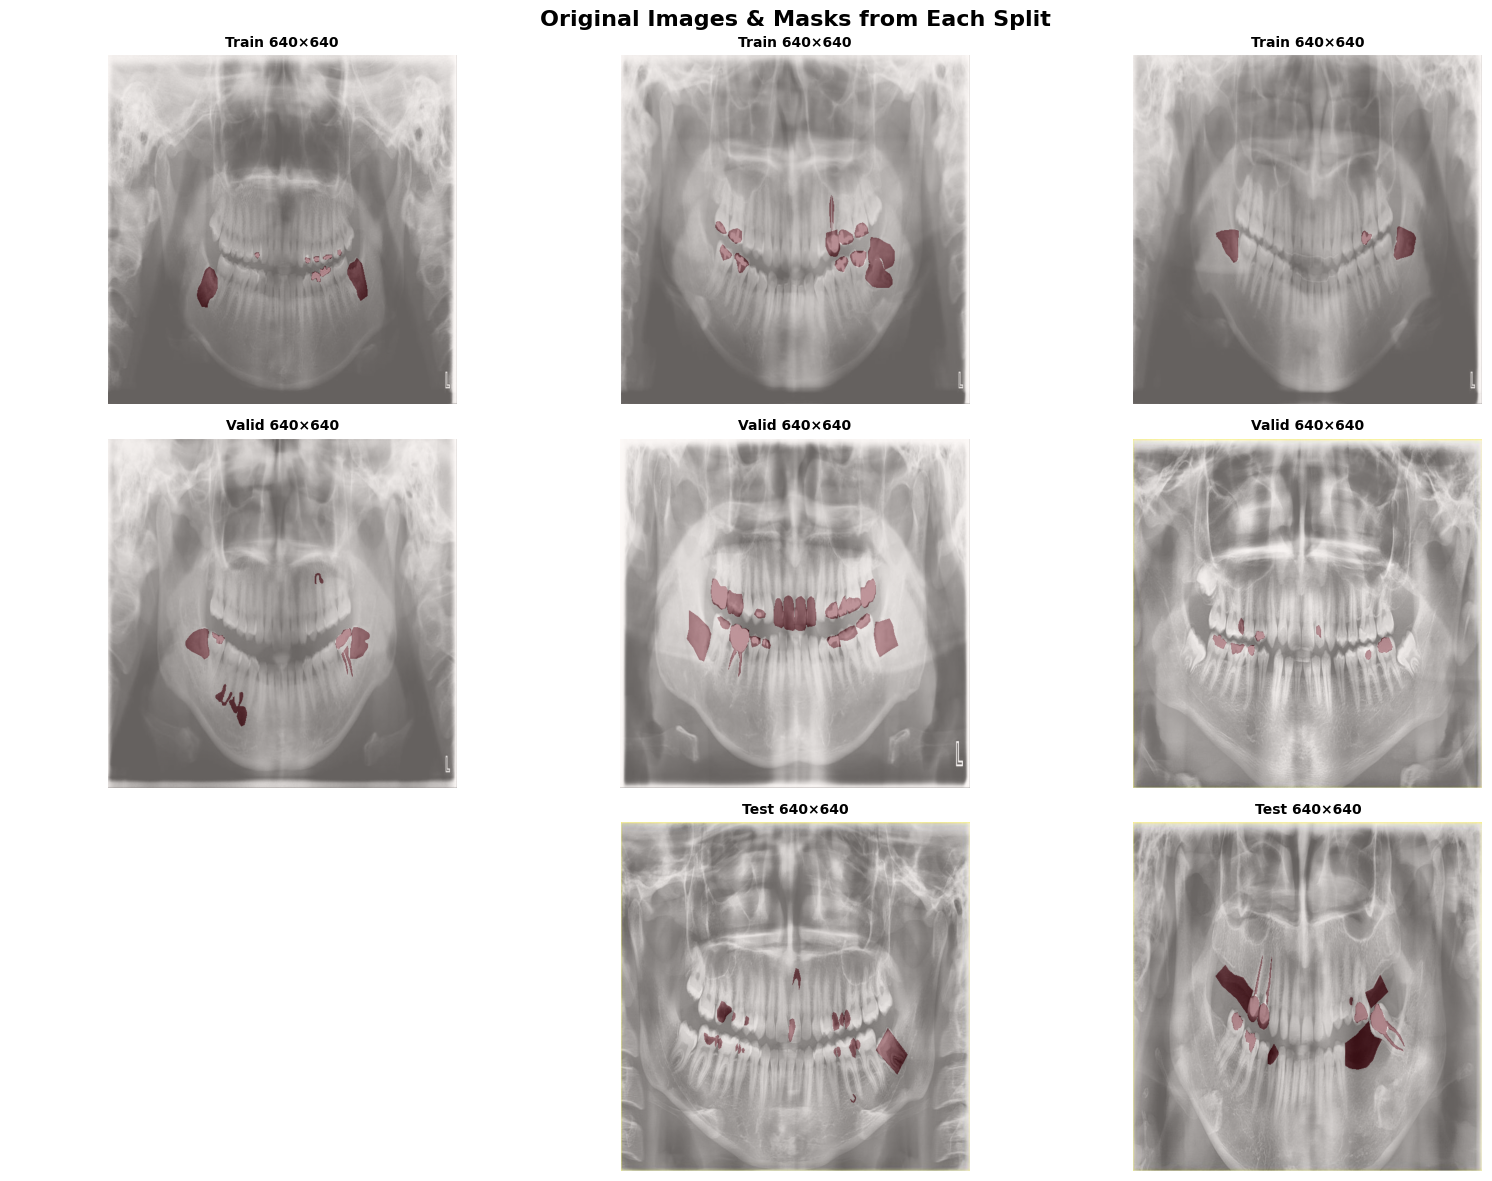

✓ Visualization complete!

✓ PHASE 3 COMPLETE!



In [ ]:
print("=" * 90)
print("PHASE 3: QUICK EDA (ORIGINAL IMAGES & MASKS)")
print("=" * 90)

print("\n📊 DATASET STATISTICS:")
print("-" * 90)
print(f"{'Split':<15} {'Images':<15} {'Height':<15} {'Width':<15}")
print("-" * 90)

all_infos = {
    'Train': train_images_info,
    'Valid': valid_images_info,
    'Test': test_images_info
}

for split_name, images_info in all_infos.items():
    if images_info:
        first_img = list(images_info.values())[0]
        print(f"{split_name:<15} {len(images_info):<15} {first_img['height']:<15} {first_img['width']:<15}")

print("\n📸 SAMPLE VISUALIZATION (Original Images + Masks):")
print("-" * 90)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Original Images & Masks from Each Split', fontsize=16, fontweight='bold')

splits_data = [
    ('Train', train_images_info, 'train', train_annotations),
    ('Valid', valid_images_info, 'valid', valid_annotations),
    ('Test', test_images_info, 'test', test_annotations)
]

for row, (split_label, images_info, split_folder, annotations) in enumerate(splits_data):
    img_ids = list(images_info.keys())[:3]

    for col, img_id in enumerate(img_ids):
        ax = axes[row, col]
        img_info = images_info[img_id]
        img_path = os.path.join(IMAGES_DIR, split_folder, img_info['filename'])

        img = cv2.imread(img_path)
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            mask = masks_cache[(split_label, img_id)]

            # Overlay
            ax.imshow(img_rgb)
            ax.imshow(mask, alpha=0.4, cmap='Reds')
            ax.set_title(f"{split_label} {img_info['width']}×{img_info['height']}",
                        fontsize=10, fontweight='bold')

        ax.axis('off')

plt.tight_layout()
plt.show()

print("✓ Visualization complete!")
print("\n✓ PHASE 3 COMPLETE!\n")


## Phase 4: Resize Images & Masks (512×512 and 800×800)

In [ ]:
print("=" * 90)
print("PHASE 4: RESIZE IMAGES & MASKS")
print("=" * 90)

# Create output directories
print("\n[1/3] Creating output directories...")

for size, dirs in OUTPUT_DIRS.items():
    for split in ['train', 'valid', 'test']:
        os.makedirs(os.path.join(dirs['images'], split), exist_ok=True)
        os.makedirs(os.path.join(dirs['masks'], split), exist_ok=True)
        print(f"  ✓ Created {size}: {split}")

# Resize function
def resize_and_save(images_info, split_folder, split_name, annotations, target_size):
    """Resize and save images and masks."""

    output_img_dir = os.path.join(OUTPUT_DIRS[target_size]['images'], split_folder)
    output_mask_dir = os.path.join(OUTPUT_DIRS[target_size]['masks'], split_folder)

    count_saved = 0

    for img_id, img_info in tqdm(images_info.items(), desc=f"  {split_name} ({target_size})", leave=False):
        img_path = os.path.join(IMAGES_DIR, split_folder, img_info['filename'])

        # Load and resize image
        img = cv2.imread(img_path)
        if img is None:
            continue

        img_resized = cv2.resize(img, (target_size, target_size), interpolation=cv2.INTER_CUBIC)

        # Save image as JPG
        output_filename = Path(img_info['filename']).stem + '.jpg'
        output_img_path = os.path.join(output_img_dir, output_filename)
        cv2.imwrite(output_img_path, img_resized, [cv2.IMWRITE_JPEG_QUALITY, 95])

        # Load and resize mask
        mask = masks_cache[(split_name, img_id)]
        mask_resized = cv2.resize(mask, (target_size, target_size), interpolation=cv2.INTER_NEAREST)

        # Save mask as PNG
        output_mask_path = os.path.join(output_mask_dir, output_filename.replace('.jpg', '.png'))
        cv2.imwrite(output_mask_path, mask_resized)

        count_saved += 1

    return count_saved

print("\n[2/3] Resizing and saving for each configuration...")

resize_summary = {}

# Process 512×512
print(f"\n  Processing 512×512 (DeepLabv3+, nnU-NET):")
count_512_train = resize_and_save(train_images_info, 'train', 'Train', train_annotations, 512)
count_512_valid = resize_and_save(valid_images_info, 'valid', 'Valid', valid_annotations, 512)
count_512_test = resize_and_save(test_images_info, 'test', 'Test', test_annotations, 512)

resize_summary[512] = {
    'train': count_512_train,
    'valid': count_512_valid,
    'test': count_512_test,
    'total': count_512_train + count_512_valid + count_512_test
}

print(f"    ✓ Train: {count_512_train}")
print(f"    ✓ Valid: {count_512_valid}")
print(f"    ✓ Test: {count_512_test}")

# Process 800×800
print(f"\n  Processing 800×800 (Mask R-CNN):")
count_800_train = resize_and_save(train_images_info, 'train', 'Train', train_annotations, 800)
count_800_valid = resize_and_save(valid_images_info, 'valid', 'Valid', valid_annotations, 800)
count_800_test = resize_and_save(test_images_info, 'test', 'Test', test_annotations, 800)

resize_summary[800] = {
    'train': count_800_train,
    'valid': count_800_valid,
    'test': count_800_test,
    'total': count_800_train + count_800_valid + count_800_test
}

print(f"    ✓ Train: {count_800_train}")
print(f"    ✓ Valid: {count_800_valid}")
print(f"    ✓ Test: {count_800_test}")

print("\n[3/3] Generating statistics...")

print(f"\n  512×512 Directory Structure:")
print(f"    DentalDatasetsReady_512/")
print(f"      train/ ({count_512_train} images + masks)")
print(f"      valid/ ({count_512_valid} images + masks)")
print(f"      test/ ({count_512_test} images + masks)")

print(f"\n  512×512 Masks Directory Structure:")
print(f"    DentalDatasetsReady_512_mask/")
print(f"      train/ ({count_512_train} masks)")
print(f"      valid/ ({count_512_valid} masks)")
print(f"      test/ ({count_512_test} masks)")

print(f"\n  800×800 Directory Structure:")
print(f"    DentalDatasetsReady_800/")
print(f"      train/ ({count_800_train} images + masks)")
print(f"      valid/ ({count_800_valid} images + masks)")
print(f"      test/ ({count_800_test} images + masks)")

print(f"\n  800×800 Masks Directory Structure:")
print(f"    DentalDatasetsReady_800_mask/")
print(f"      train/ ({count_800_train} masks)")
print(f"      valid/ ({count_800_valid} masks)")
print(f"      test/ ({count_800_test} masks)")

print("\n✓ PHASE 4 COMPLETE!\n")


PHASE 4: RESIZE IMAGES & MASKS

[1/3] Creating output directories...
  ✓ Created 512: train
  ✓ Created 512: valid
  ✓ Created 512: test
  ✓ Created 800: train
  ✓ Created 800: valid
  ✓ Created 800: test

[2/3] Resizing and saving for each configuration...

  Processing 512×512 (DeepLabv3+, nnU-NET):


  Train (512):   0%|          | 0/4772 [00:00<?, ?it/s]

    ✓ Train: 4772
    ✓ Valid: 2071
    ✓ Test: 1345

  Processing 800×800 (Mask R-CNN):


    ✓ Train: 4772
    ✓ Valid: 2071
    ✓ Test: 1345

[3/3] Generating statistics...

  512×512 Directory Structure:
    DentalDatasetsReady_512/
      train/ (4772 images + masks)
      valid/ (2071 images + masks)
      test/ (1345 images + masks)

  512×512 Masks Directory Structure:
    DentalDatasetsReady_512_mask/
      train/ (4772 masks)
      valid/ (2071 masks)
      test/ (1345 masks)

  800×800 Directory Structure:
    DentalDatasetsReady_800/
      train/ (4772 images + masks)
      valid/ (2071 images + masks)
      test/ (1345 images + masks)

  800×800 Masks Directory Structure:
    DentalDatasetsReady_800_mask/
      train/ (4772 masks)
      valid/ (2071 masks)
      test/ (1345 masks)

✓ PHASE 4 COMPLETE!



## Phase 5: Validation & Verification

PHASE 5: VALIDATION & VERIFICATION

[1/3] Verifying file counts...
  ✓ 512×512 Train: 4772 images, 4772 masks
  ✓ 512×512 Valid: 2071 images, 2071 masks
  ✓ 512×512 Test: 1345 images, 1345 masks
  ✓ 800×800 Train: 4772 images, 4772 masks
  ✓ 800×800 Valid: 2071 images, 2071 masks
  ✓ 800×800 Test: 1345 images, 1345 masks

[2/3] Checking image dimensions...
  ✓ 512×512 train: image 512×512, mask 512×512
  ✓ 512×512 valid: image 512×512, mask 512×512
  ✓ 800×800 train: image 800×800, mask 800×800
  ✓ 800×800 valid: image 800×800, mask 800×800

[3/3] Visual verification (sample resized images + masks)...


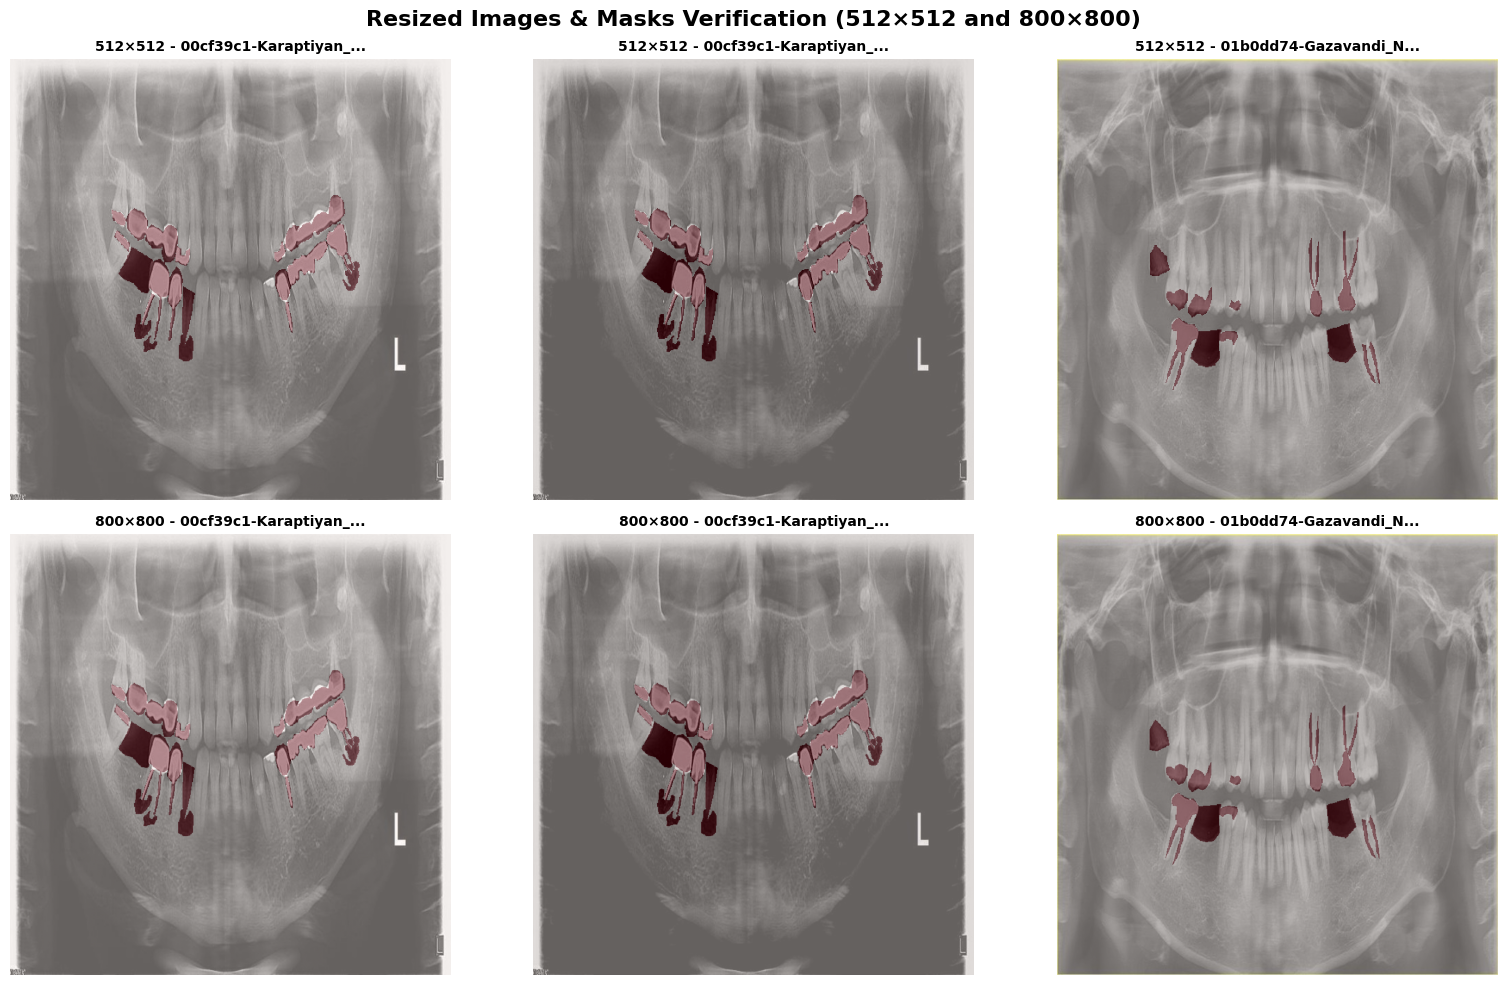

✓ Visual verification complete!

✅ ALL VALIDATION CHECKS PASSED!

✓ PHASE 5 COMPLETE!



In [ ]:
print("=" * 90)
print("PHASE 5: VALIDATION & VERIFICATION")
print("=" * 90)

print("\n[1/3] Verifying file counts...")

def verify_split(size, split_name, split_folder, expected_count):
    """Verify files in a split."""
    img_dir = os.path.join(OUTPUT_DIRS[size]['images'], split_folder)
    mask_dir = os.path.join(OUTPUT_DIRS[size]['masks'], split_folder)

    img_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
    mask_files = [f for f in os.listdir(mask_dir) if f.endswith('.png')]

    img_match = len(img_files) == expected_count
    mask_match = len(mask_files) == expected_count

    status = "✓" if (img_match and mask_match) else "✗"
    print(f"  {status} {size}×{size} {split_name}: {len(img_files)} images, {len(mask_files)} masks")

    return img_match and mask_match

all_valid = True
all_valid &= verify_split(512, 'Train', 'train', resize_summary[512]['train'])
all_valid &= verify_split(512, 'Valid', 'valid', resize_summary[512]['valid'])
all_valid &= verify_split(512, 'Test', 'test', resize_summary[512]['test'])
all_valid &= verify_split(800, 'Train', 'train', resize_summary[800]['train'])
all_valid &= verify_split(800, 'Valid', 'valid', resize_summary[800]['valid'])
all_valid &= verify_split(800, 'Test', 'test', resize_summary[800]['test'])

print("\n[2/3] Checking image dimensions...")

def check_dimensions(size, split_folder):
    """Verify dimensions of saved files."""
    img_dir = os.path.join(OUTPUT_DIRS[size]['images'], split_folder)
    mask_dir = os.path.join(OUTPUT_DIRS[size]['masks'], split_folder)

    # Check first image
    img_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
    if img_files:
        test_img = cv2.imread(os.path.join(img_dir, img_files[0]))
        h, w = test_img.shape[:2]

        # Check first mask
        mask_files = [f for f in os.listdir(mask_dir) if f.endswith('.png')]
        test_mask = cv2.imread(os.path.join(mask_dir, mask_files[0]), cv2.IMREAD_GRAYSCALE)
        mh, mw = test_mask.shape[:2]

        match = (h == w == size) and (mh == mw == size)
        status = "✓" if match else "✗"
        print(f"  {status} {size}×{size} {split_folder}: image {h}×{w}, mask {mh}×{mw}")

        return match
    return False

check_dimensions(512, 'train')
check_dimensions(512, 'valid')
check_dimensions(800, 'train')
check_dimensions(800, 'valid')

print("\n[3/3] Visual verification (sample resized images + masks)...")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Resized Images & Masks Verification (512×512 and 800×800)', fontsize=16, fontweight='bold')

sizes = [512, 800]
for row, size in enumerate(sizes):
    img_dir = os.path.join(OUTPUT_DIRS[size]['images'], 'train')
    mask_dir = os.path.join(OUTPUT_DIRS[size]['masks'], 'train')

    img_files = sorted([f for f in os.listdir(img_dir) if f.endswith('.jpg')])[:3]

    for col, img_file in enumerate(img_files):
        ax = axes[row, col]

        # Load image
        img_path = os.path.join(img_dir, img_file)
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Load mask
        mask_file = img_file.replace('.jpg', '.png')
        mask_path = os.path.join(mask_dir, mask_file)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Overlay
        ax.imshow(img_rgb)
        ax.imshow(mask, alpha=0.4, cmap='Reds')
        ax.set_title(f"{size}×{size} - {img_file[:20]}...", fontsize=10, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()

print("✓ Visual verification complete!")

if all_valid:
    print("\n" + "=" * 90)
    print("✅ ALL VALIDATION CHECKS PASSED!")
    print("=" * 90)
else:
    print("\n⚠ Some validation checks failed!")

print("\n✓ PHASE 5 COMPLETE!\n")


## Phase 6: Summary & Final Report

In [ ]:
print("=" * 90)
print("PHASE 6: SUMMARY & FINAL REPORT")
print("=" * 90)

print("\n" + "=" * 90)
print("PREPROCESSING COMPLETE!")
print("=" * 90)

print("\n📁 OUTPUT DIRECTORIES CREATED:")
print("-" * 90)

print("\n512×512 Images (DeepLabv3+, nnU-NET):")
print(f"  {OUTPUT_DIRS[512]['images']}/")
print(f"    ├─ train/  ({count_512_train} images)")
print(f"    ├─ valid/  ({count_512_valid} images)")
print(f"    └─ test/   ({count_512_test} images)")

print("\n512×512 Masks:")
print(f"  {OUTPUT_DIRS[512]['masks']}/")
print(f"    ├─ train/  ({count_512_train} masks)")
print(f"    ├─ valid/  ({count_512_valid} masks)")
print(f"    └─ test/   ({count_512_test} masks)")

print("\n800×800 Images (Mask R-CNN):")
print(f"  {OUTPUT_DIRS[800]['images']}/")
print(f"    ├─ train/  ({count_800_train} images)")
print(f"    ├─ valid/  ({count_800_valid} images)")
print(f"    └─ test/   ({count_800_test} images)")

print("\n800×800 Masks:")
print(f"  {OUTPUT_DIRS[800]['masks']}/")
print(f"    ├─ train/  ({count_800_train} masks)")
print(f"    ├─ valid/  ({count_800_valid} masks)")
print(f"    └─ test/   ({count_800_test} masks)")

print("\n" + "=" * 90)
print("📊 DATA SUMMARY")
print("=" * 90)

print(f"\n512×512 (DeepLabv3+, nnU-NET):")
print(f"  Total images: {resize_summary[512]['total']}")
print(f"  Format: JPG (quality 95)")
print(f"  Train: {count_512_train} | Valid: {count_512_valid} | Test: {count_512_test}")

print(f"\n800×800 (Mask R-CNN):")
print(f"  Total images: {resize_summary[800]['total']}")
print(f"  Format: JPG (quality 95)")
print(f"  Train: {count_800_train} | Valid: {count_800_valid} | Test: {count_800_test}")

print(f"\nMasks (Both Sizes):")
print(f"  Format: PNG (lossless, binary)")
print(f"  Total: {resize_summary[512]['total'] + resize_summary[800]['total']} masks")

print("\n" + "=" * 90)
print("📋 HOW TO USE IN PYTORCH")
print("=" * 90)

usage_code = '''
# Example: Load 512×512 data for DeepLabv3+
from pathlib import Path
import cv2
import torch
from torch.utils.data import Dataset, DataLoader

class DentalDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.image_files = sorted(self.images_dir.glob('*.jpg'))
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        mask_path = self.masks_dir / img_path.name.replace('.jpg', '.png')

        # Load image
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype('float32') / 255.0

        # Load mask
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE).astype('float32') / 255.0
        mask = mask[..., np.newaxis]  # Add channel dimension

        if self.transform:
            image, mask = self.transform(image, mask)

        return torch.from_numpy(image).permute(2, 0, 1), torch.from_numpy(mask).permute(2, 0, 1)

# For 512×512 (DeepLabv3+)
train_dataset = DentalDataset(
    images_dir='DentalDatasetsReady_512/train',
    masks_dir='DentalDatasetsReady_512_mask/train'
)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# For 800×800 (Mask R-CNN)
train_dataset = DentalDataset(
    images_dir='DentalDatasetsReady_800/train',
    masks_dir='DentalDatasetsReady_800_mask/train'
)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
'''

print(usage_code)

print("\n" + "=" * 90)
print("✅ PREPROCESSING SUCCESSFUL!")
print("=" * 90)
print("\nAll data is ready for training with PyTorch!")
print(f"GPU Status: {'Available' if torch.cuda.is_available() else 'Not available'}")


PHASE 6: SUMMARY & FINAL REPORT

PREPROCESSING COMPLETE!

📁 OUTPUT DIRECTORIES CREATED:
------------------------------------------------------------------------------------------

512×512 Images (DeepLabv3+, nnU-NET):
  c:\Users\hadid\OneDrive\Documents\1 VScode\Python\4 Semester\4 DL\Day7\DentalDatasetsReady_512/
    ├─ train/  (4772 images)
    ├─ valid/  (2071 images)
    └─ test/   (1345 images)

512×512 Masks:
  c:\Users\hadid\OneDrive\Documents\1 VScode\Python\4 Semester\4 DL\Day7\DentalDatasetsReady_512_mask/
    ├─ train/  (4772 masks)
    ├─ valid/  (2071 masks)
    └─ test/   (1345 masks)

800×800 Images (Mask R-CNN):
  c:\Users\hadid\OneDrive\Documents\1 VScode\Python\4 Semester\4 DL\Day7\DentalDatasetsReady_800/
    ├─ train/  (4772 images)
    ├─ valid/  (2071 images)
    └─ test/   (1345 images)

800×800 Masks:
  c:\Users\hadid\OneDrive\Documents\1 VScode\Python\4 Semester\4 DL\Day7\DentalDatasetsReady_800_mask/
    ├─ train/  (4772 masks)
    ├─ valid/  (2071 masks)
    